# Stacking Classifier - Weather Rain Prediction

## 1. Load Weather Dataset from Stacking Folder
Load the available weather dataset from the local stacking classifier folder and verify the file path.

In [1]:
import pandas as pd
from pathlib import Path

pd.set_option("display.max_columns", None)

data_path = Path("weather_forecast_data.csv")
if not data_path.exists():
    raise FileNotFoundError(f"Dataset not found at: {data_path.resolve()}")

df = pd.read_csv(data_path)
print("Shape:", df.shape)
df.head()

Shape: (2500, 6)


,Temperature,Humidity,Wind_Speed,Cloud_Cover,Pressure,Rain
0,23.720338,89.592641,7.335604,50.501694,1032.378759,rain
1,27.879734,46.489704,5.952484,4.990053,992.614190,no rain
2,25.069084,83.072843,1.371992,14.855784,1007.231620,no rain
3,23.622080,74.367758,7.050551,67.255282,982.632013,rain
4,20.591370,96.858822,4.643921,47.676444,980.825142,no rain


## 2. Inspect and Clean Data
Display schema, handle missing values, fix data types, and remove or impute invalid rows.

In [2]:
df.info()

numeric_cols = ["Temperature", "Humidity", "Wind_Speed", "Cloud_Cover", "Pressure"]

# Normalize target labels and coerce numeric columns
if "Rain" not in df.columns:
    raise ValueError("Expected target column 'Rain' not found.")

df["Rain"] = df["Rain"].astype(str).str.strip().str.lower()
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df = df.dropna(subset=numeric_cols + ["Rain"]).reset_index(drop=True)
print("After cleaning:", df.shape)
print(df["Rain"].value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Temperature  2500 non-null   float64
 1   Humidity     2500 non-null   float64
 2   Wind_Speed   2500 non-null   float64
 3   Cloud_Cover  2500 non-null   float64
 4   Pressure     2500 non-null   float64
 5   Rain         2500 non-null   object 
dtypes: float64(5), object(1)
memory usage: 117.3+ KB
After cleaning: (2500, 6)
Rain
no rain    2186
rain        314
Name: count, dtype: int64


## 3. Feature Engineering and Encoding
Create/select features, encode the target, and prepare the feature matrix.

In [3]:
X = df[numeric_cols].copy()
y = df["Rain"].map({"no rain": 0, "rain": 1})

if y.isna().any():
    unknown = df.loc[y.isna(), "Rain"].unique().tolist()
    raise ValueError(f"Unknown target labels found: {unknown}")

print("Target distribution:")
print(y.value_counts(normalize=True))

Target distribution:
Rain
0    0.8744
1    0.1256
Name: proportion, dtype: float64


## 4. Train/Validation/Test Split
Split the dataset into train/validation/test sets with a fixed random seed and stratification.

In [4]:
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(
 
    X, y, test_size=0.30, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

print("Train:", X_train.shape, "Val:", X_val.shape, "Test:", X_test.shape)

Train: (1750, 5) Val: (375, 5) Test: (375, 5)


## 5. Define Base Models
Instantiate all base learners used in the project with consistent pipelines.

In [5]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, StackingClassifier

base_models = {
    "Logistic Regression": Pipeline(
        [("scaler", StandardScaler()), ("model", LogisticRegression(max_iter=1000))]
    ),
    "KNN": Pipeline(
        [("scaler", StandardScaler()), ("model", KNeighborsClassifier(n_neighbors=5))]
    ),
    "SVM (RBF)": Pipeline(
        [("scaler", StandardScaler()), ("model", SVC(kernel="rbf", probability=True))]
    ),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
}

## 6. Train and Evaluate Individual Base Models
Train each model, generate predictions, and compute evaluation metrics.

In [6]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
)


def evaluate_model(name, model, X_train, y_train, X_eval, y_eval):
    model.fit(X_train, y_train)
    preds = model.predict(X_eval)
    metrics = {
        "model": name,
        "accuracy": accuracy_score(y_eval, preds),
        "precision": precision_score(y_eval, preds),
        "recall": recall_score(y_eval, preds),
        "f1": f1_score(y_eval, preds),
    }
    if hasattr(model, "predict_proba"):
        proba = model.predict_proba(X_eval)[:, 1]
        metrics["roc_auc"] = roc_auc_score(y_eval, proba)
    else:
        metrics["roc_auc"] = float("nan")
    return metrics, model

results = []
trained_models = {}

for name, model in base_models.items():
    metrics, fitted = evaluate_model(name, model, X_train, y_train, X_test, y_test)
    results.append(metrics)
    trained_models[name] = fitted

pd.DataFrame(results).sort_values("f1", ascending=False)

,model,accuracy,precision,recall,f1,roc_auc
4,Random Forest,1.000000,1.000000,1.000000,1.000000,1.000000
3,Decision Tree,0.997333,0.979167,1.000000,0.989474,0.998476
1,KNN,0.970667,0.909091,0.851064,0.879121,0.981415
2,SVM (RBF),0.968000,0.926829,0.808511,0.863636,0.992929
0,Logistic Regression,0.928000,0.763158,0.617021,0.682353,0.971264


## 7. Build Stacking Classifier
Create a stacking ensemble using the base models and a meta-learner, then fit it.

In [7]:
estimators = [(name, model) for name, model in base_models.items()]

stacking = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression(max_iter=1000),
    stack_method="predict_proba",
    passthrough=False,
)

stack_metrics, stacking_model = evaluate_model(
    "Stacking (LR meta)", stacking, X_train, y_train, X_test, y_test
)
results.append(stack_metrics)

print(stack_metrics)

{'model': 'Stacking (LR meta)', 'accuracy': 0.9973333333333333, 'precision': 0.9791666666666666, 'recall': 1.0, 'f1': 0.9894736842105263, 'roc_auc': 1.0}


## 8. Evaluate Stacking vs Individual Models
Compare stacking performance against all base models on the test set.

In [8]:
comparison_df = (
    pd.DataFrame(results)
    .sort_values("f1", ascending=False)
    .reset_index(drop=True)
)
comparison_df

,model,accuracy,precision,recall,f1,roc_auc
0,Random Forest,1.000000,1.000000,1.000000,1.000000,1.000000
1,Decision Tree,0.997333,0.979167,1.000000,0.989474,0.998476
2,Stacking (LR meta),0.997333,0.979167,1.000000,0.989474,1.000000
3,KNN,0.970667,0.909091,0.851064,0.879121,0.981415
4,SVM (RBF),0.968000,0.926829,0.808511,0.863636,0.992929
5,Logistic Regression,0.928000,0.763158,0.617021,0.682353,0.971264


## 9. Performance Comparison Table and Plot
Create a summary table and visualization of model metrics, then save the stacking model.

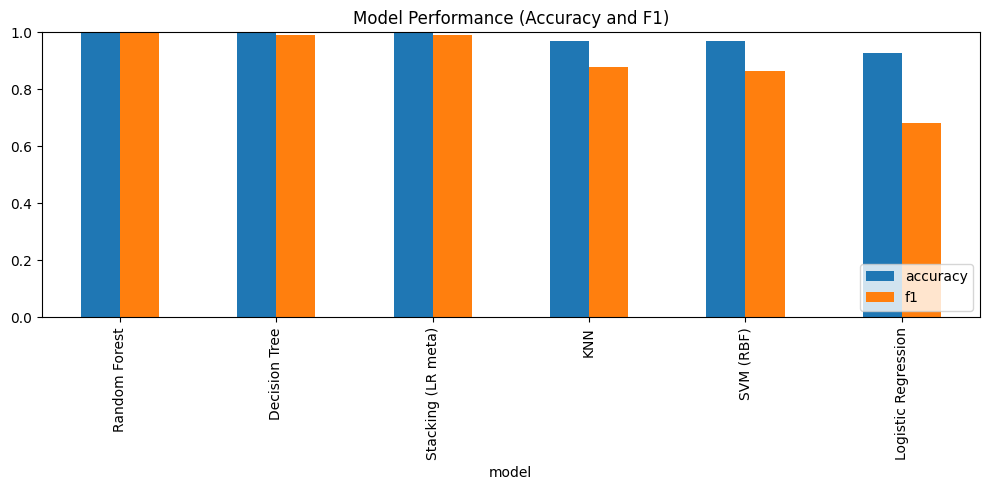

Saved model to stacking_rain_model.pkl


In [9]:
import matplotlib.pyplot as plt
import joblib

plot_df = comparison_df.set_index("model")[["accuracy", "f1"]]
ax = plot_df.plot(kind="bar", figsize=(10, 5))
ax.set_title("Model Performance (Accuracy and F1)")
ax.set_ylim(0, 1)
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

joblib.dump(stacking_model, "stacking_rain_model.pkl")
print("Saved model to stacking_rain_model.pkl")